In [44]:
import pandas as pd
import numpy as np

In [45]:
df = pd.read_csv('../raw_data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [46]:
df.shape

(768, 9)

In [47]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [48]:
# looks like we are good here.
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [49]:
df = df[['Glucose', 'BMI', 'BloodPressure']]

In [50]:
df.to_csv("../clean_data/clean_diabetes.csv", index=False)

# A) Compare Sample

In [51]:

dfs = df.sample(25,random_state=2)
dfs.head()

,Glucose,BMI,BloodPressure
158,88,29.0,74
251,129,28.0,84
631,102,34.5,78
757,123,36.3,72
689,144,46.1,82


In [52]:
import matplotlib.pyplot as plt

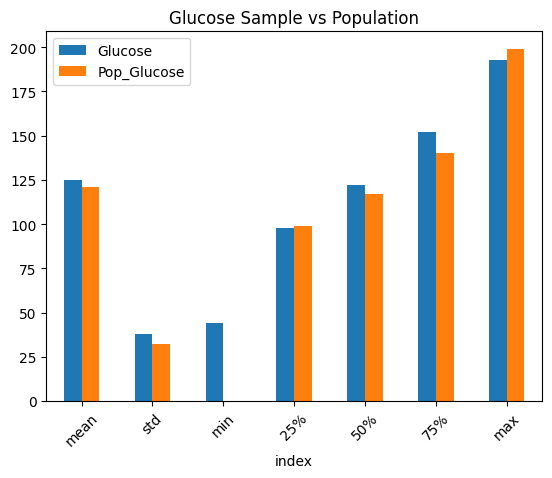

In [53]:
sample = dfs['Glucose'].describe().reset_index()
pop = df['Glucose'].describe().reset_index()

sample['Pop_Glucose'] = pop['Glucose'] 
sample.set_index('index').drop(index='count').plot.bar(rot=45, title='Glucose Sample vs Population')

plt.savefig("../reports/glucose.svg")


In [54]:
sample

,index,Glucose,Pop_Glucose
0,count,25.000,768.000000
1,mean,124.800,120.894531
2,std,38.139,31.972618
3,min,44.000,0.000000
4,25%,98.000,99.000000
5,50%,122.000,117.000000
6,75%,152.000,140.250000
7,max,193.000,199.000000


# B) Compare BMI

47.972 47.52599999999996


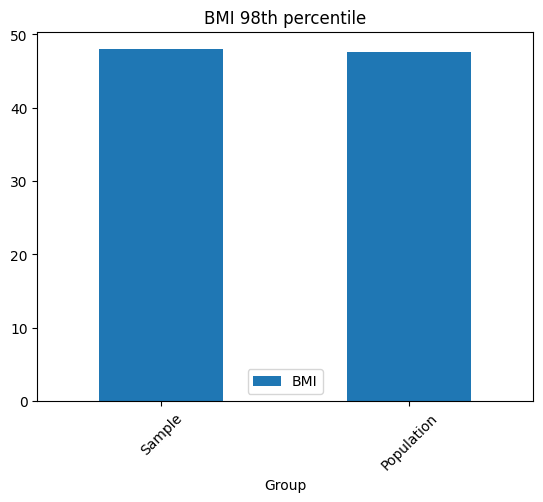

In [55]:
sample = dfs['BMI'].quantile(0.98)
pop = df['BMI'].quantile(0.98)

print(sample, pop)

pd.DataFrame({
    'Group': ['Sample', 'Population'],
    'BMI': [sample, pop]
}).set_index('Group').plot.bar(rot=45, title='BMI 98th percentile')

plt.savefig("../reports/bmi-bar.svg")

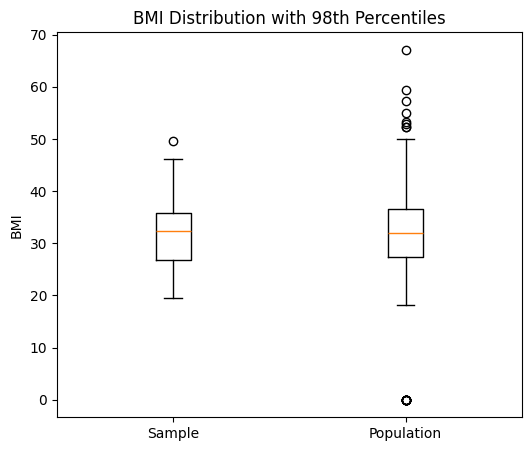

In [56]:
import matplotlib.pyplot as plt

ax = plt.figure(figsize=(6,5)).gca()

ax.boxplot([dfs['BMI'], df['BMI']], tick_labels=['Sample', 'Population'])

plt.ylabel("BMI")
plt.title("BMI Distribution with 98th Percentiles")

plt.savefig('../reports/bmi-hist.svg')

# C) Bootstrap

In [57]:
pd.concat([df['BloodPressure'].sample(150, replace=True, random_state=0).describe(), df['BloodPressure'].sample(150, replace=True, random_state=1).describe()]).reset_index().set_index('index').groupby(by='index').mean()

,BloodPressure
index,
25%,62.125000
50%,72.000000
75%,80.750000
count,150.000000
max,110.000000
mean,69.116667
min,0.000000
std,19.204334


In [58]:
n=500
samples = []
for i in range(n):
    bp = df['BloodPressure'].sample(150, replace=True, random_state=i)
    samples.append(bp.describe())

sample_stats = pd.concat(samples).reset_index().set_index('index').groupby(by='index').mean()
sample_stats

,BloodPressure
index,
25%,63.012500
50%,71.485000
75%,79.512000
count,150.000000
max,110.748000
mean,69.171987
min,0.000000
std,19.202760


In [59]:
pop_stats = df['BloodPressure'].describe()

sample_stats['Pop_BloodPressure'] = pop_stats
sample_stats

,BloodPressure,Pop_BloodPressure
index,,
25%,63.012500,62.000000
50%,71.485000,72.000000
75%,79.512000,80.000000
count,150.000000,768.000000
max,110.748000,122.000000
mean,69.171987,69.105469
min,0.000000,0.000000
std,19.202760,19.355807


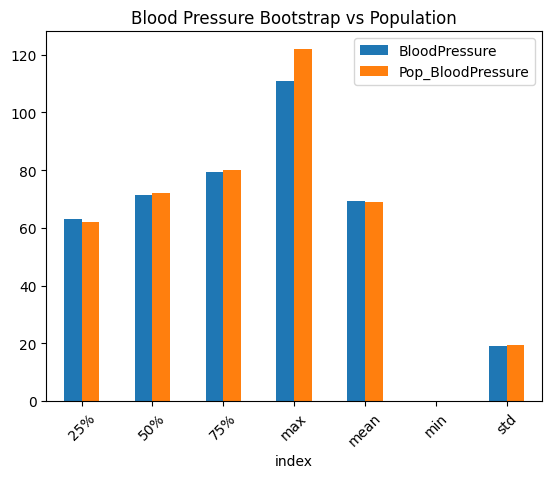

In [60]:
sample_stats.drop(index='count').plot.bar(rot=45, title='Blood Pressure Bootstrap vs Population')

plt.savefig('../reports/bp.svg')